# "SHAP"을 활용한 당뇨병 발병 여부 예측 모델 해석하기

## 개요
- Pima Indians Diabetes 데이터셋으로 **당뇨병 발병 여부** 예측
- **SHAP (SHapley Additive exPlanations)**: 모델 예측을 설명하는 최신 기법
- **3가지 Gradient Boosting 모델** 해석: XGBoost, LightGBM, CatBoost
- 전역적 해석(Global) + 지역적 해석(Local)

## 주요 단계
1. 데이터 로드 및 모델 학습
2. SHAP 기본 개념 이해
3. 전역적 특성 중요도 분석
4. 개별 예측 해석
5. 특성 간 상호작용 분석
6. 의사결정 시각화

In [22]:
!pip install shap xgboost catboost  koreanize-matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import shap
shap.initjs()  # JavaScript 시각화 초기화

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드

**Pima Indians Diabetes 데이터셋**
- 768개 샘플, 8개 피처
- 당뇨병 발병 여부 이진 분류
- 피처명:
  - preg: 임신 횟수
  - plas: 혈당 농도
  - pres: 혈압
  - skin: 피부 두께
  - insu: 인슐린
  - mass: BMI
  - pedi: 당뇨병 가족력
  - age: 나이

In [15]:
# as_frame: pandas DataFrame 형태로 가져올 것인가 -> feature: DataFrame, target: Series
pima = fetch_openml(name='diabetes', version=1, as_frame=True)
pima

{'data':      preg  plas  pres  skin  insu  mass   pedi  age
 0       6   148    72    35     0  33.6  0.627   50
 1       1    85    66    29     0  26.6  0.351   31
 2       8   183    64     0     0  23.3  0.672   32
 3       1    89    66    23    94  28.1  0.167   21
 4       0   137    40    35   168  43.1  2.288   33
 ..    ...   ...   ...   ...   ...   ...    ...  ...
 763    10   101    76    48   180  32.9  0.171   63
 764     2   122    70    27     0  36.8  0.340   27
 765     5   121    72    23   112  26.2  0.245   30
 766     1   126    60     0     0  30.1  0.349   47
 767     1    93    70    31     0  30.4  0.315   23
 
 [768 rows x 8 columns],
 'target': 0      tested_positive
 1      tested_negative
 2      tested_positive
 3      tested_negative
 4      tested_positive
             ...       
 763    tested_negative
 764    tested_negative
 765    tested_negative
 766    tested_positive
 767    tested_negative
 Name: class, Length: 768, dtype: category
 Categories 

In [16]:
X = pima.data
y = pima.target.map({'tested_negative': 0, 'tested_positive': 1}).astype(int)   # target의 문자열을 숫자형으로

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"\n클래스 분포:\n{y.value_counts()}")
print(f"\n클래스 비율:\n{y.value_counts(normalize=True).round(3)}")

데이터 크기: (768, 8)
피처 목록: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

클래스 분포:
class
0    500
1    268
Name: count, dtype: int64

클래스 비율:
class
0    0.651
1    0.349
Name: proportion, dtype: float64


In [17]:
# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 피처명 저장
feature_names = X.columns.tolist()

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"\ny_train 클래스 분포:\n{y_train.value_counts()}")
print(f"\n피처 개수: {len(feature_names)}개")

X_train: (614, 8), X_test: (154, 8)
y_train: (614,), y_test: (154,)

y_train 클래스 분포:
class
0    400
1    214
Name: count, dtype: int64

피처 개수: 8개


## 2. 모델 학습

**3가지 Gradient Boosting 모델 학습**
- XGBoost
- LightGBM
- CatBoost

In [19]:
# XGBoost - 이전 오차 보완. level-wise 로 트리 키우는 방식
print("\n1. XGBoost 학습 중...")
xgb_model = XGBClassifier(
    n_estimators=100,   # 생성할 트리 개수
    max_depth=5,        # 트리 최대 깊이
    learning_rate=0.1,  # 학습률 - 크면 빠르게, 작으면 천천히 학습.
    random_state=42,
    eval_metric='logloss', # 모델 성능 평가 기준 - logloss: 예측 확률이 정답과 얼마나 잘 맞는지.(이진분류 시 자주 사용)
    use_label_encoder=False
)

# 학습
xgb_model.fit(X_train, y_train)

# 예측
xgb_pred = xgb_model.predict(X_test)

# 예측 정확도
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Test Accuracy: {xgb_acc:.4f}")


1. XGBoost 학습 중...
XGBoost Test Accuracy: 0.7792


In [20]:
# LightGBM - 여러 개 DecisionTree 순차 학습 해 이전 모델 실수 보완. leaf-wise 방식.
print("\n2. LightGBM 학습 중...")
lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=-1  # 학습 중 메시지 출력 여부
)

# 학습
lgbm_model.fit(X_train, y_train)

# 예측
lgbm_pred = lgbm_model.predict(X_test)

# 예측 정확도
lgbm_acc = accuracy_score(y_test, lgbm_pred)
print(f"LightGBM Test Accuracy: {lgbm_acc:.4f}")


2. LightGBM 학습 중...
LightGBM Test Accuracy: 0.7727


In [21]:
# CatBoost - 범주형 데이터 특화 부스팅 모델.
print("\n3. CatBoost 학습 중...")
cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)

# 학습
cat_model.fit(X_train, y_train)

# 예측
cat_pred = cat_model.predict(X_test)

# 예측 정확도
cat_acc = accuracy_score(y_test, cat_pred)
print(f"CatBoost Test Accuracy: {cat_acc:.4f}")


3. CatBoost 학습 중...
CatBoost Test Accuracy: 0.7403


## 3. Shap Explainer(모델 예측 이유 설명)

**SHAP Explainer 종류**
- TreeExplainer: Tree 기반 모델 (빠르고 정확)
- KernelExplainer: 모든 모델 (느리지만 범용적)
- DeepExplainer: 딥러닝 모델
- LinearExplainer: 선형 모델

In [24]:
# XGBoost Explainer - 트리 기반 => TreeExplainer
print("\n1. XGBoost TreeExplainer 생성...")
explainer_xgb = shap.TreeExplainer(xgb_model)   # 트리 기반 모델용 Shap Explainer 생성.
shap_values_xgb = explainer_xgb.shap_values(X_test) # shap 계산.(각 feature가 예측 결과에 미치는 영향 계산결과)
print(f"XGB_SHAP values shape: {shap_values_xgb.shape}")


1. XGBoost TreeExplainer 생성...
XGB_SHAP values shape: (154, 8)


In [25]:
# LightGBM Explainer - 트리 기반 => TreeExplainer
print("\n2. LightGBM TreeExplainer 생성...")
explainer_lgbm = shap.TreeExplainer(lgbm_model)
shap_values_lgbm = explainer_lgbm.shap_values(X_test)

# LightGBM은 2차원 배열 반환할 수 있음 (binary classification)
# positive class에 대한 shap 값만 사용하겠다.
if isinstance(shap_values_lgbm, list):  # 리스트 형태인가?
    shap_values_lgbm = shap_values_lgbm[1]  # Positive class
print(f"LGBM_SHAP values shape: {shap_values_lgbm.shape}")


2. LightGBM TreeExplainer 생성...
LGBM_SHAP values shape: (154, 8)


In [26]:
# CatBoost Explainer - 트리 기반 => TreeExplainer
print("\n3. CatBoost TreeExplainer 생성...")
explainer_cat = shap.TreeExplainer(cat_model)
shap_values_cat = explainer_cat.shap_values(X_test)
print(f"CAT_SHAP values shape: {shap_values_cat.shape}")


3. CatBoost TreeExplainer 생성...
CAT_SHAP values shape: (154, 8)


## 4.Global Feature Importance(전역적 특성 중요도)

**전역적 해석**
- 전체 데이터셋에서 각 특성이 얼마나 중요한지 분석
- Summary Plot: 모든 샘플의 SHAP 값 분포
- Bar Plot: 평균 절대 SHAP 값으로 중요도 순위

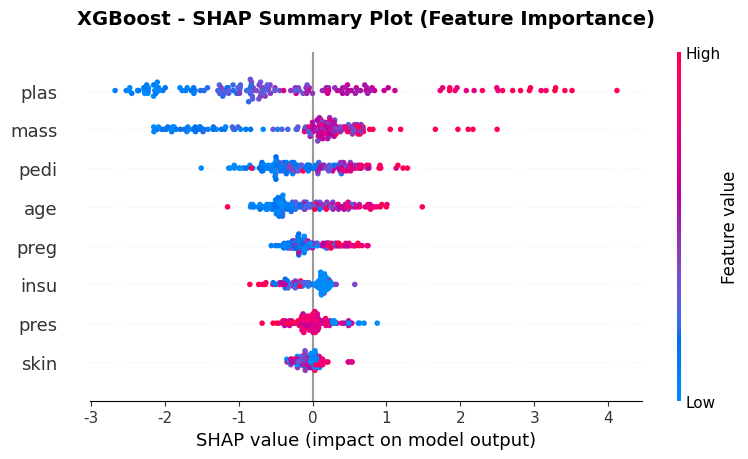

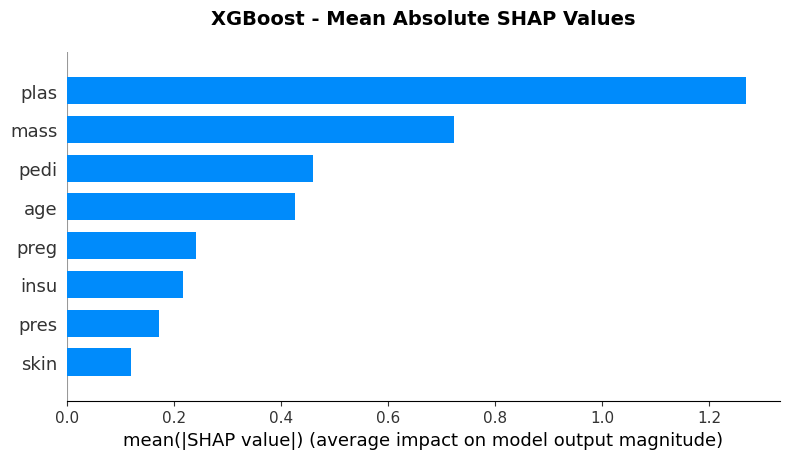

In [35]:
# XGBoost SHAP 분석
# Summary Plot (Beeswarm)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_xgb,
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title('XGBoost - SHAP Summary Plot (Feature Importance)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Bar Plot (평균 절대 SHAP 값)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_xgb,
    X_test,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('XGBoost - Mean Absolute SHAP Values', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

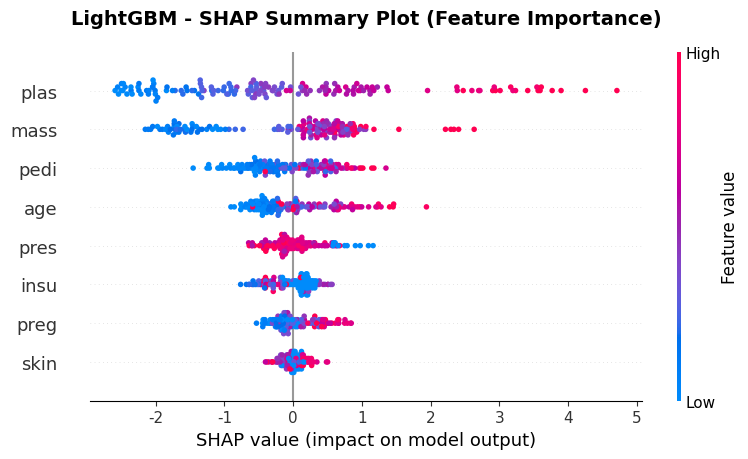

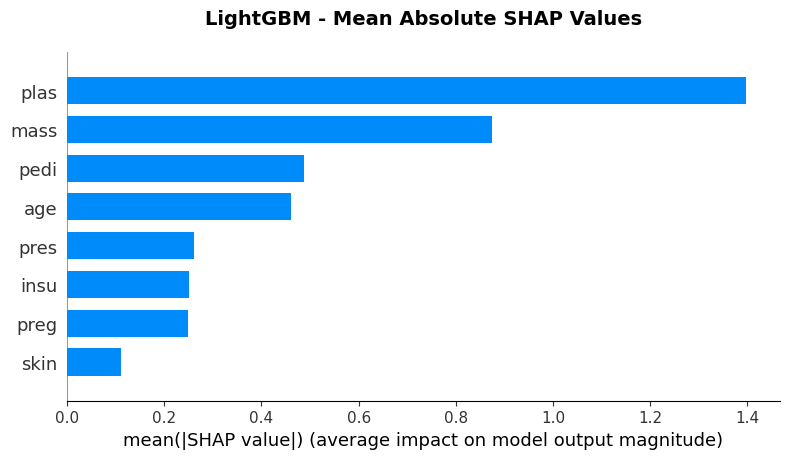

In [34]:
# LightGBM SHAP 분석

# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_lgbm,
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title('LightGBM - SHAP Summary Plot (Feature Importance)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_lgbm,
    X_test,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('LightGBM - Mean Absolute SHAP Values', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

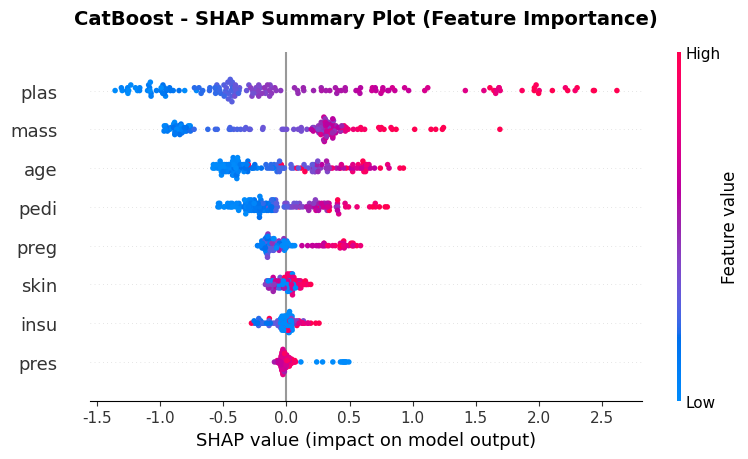

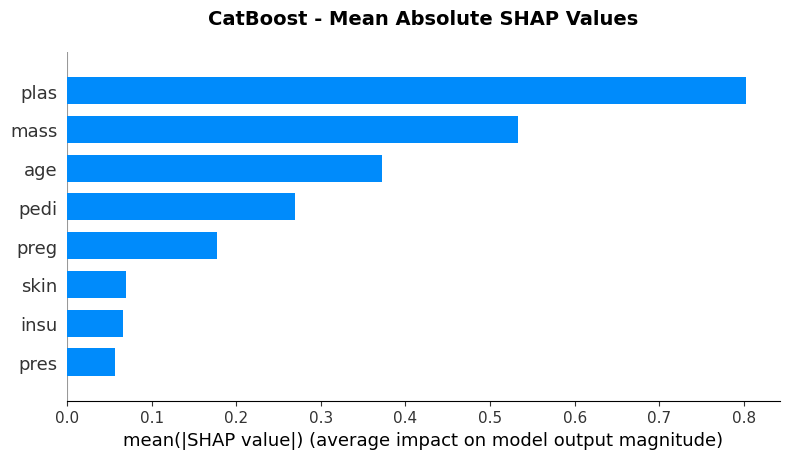

In [36]:
# CatBoost SHAP 분석

# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cat, X_test, feature_names=feature_names, show=False)
plt.title('CatBoost - SHAP Summary Plot (Feature Importance)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cat, X_test, feature_names=feature_names, plot_type='bar', show=False)
plt.title('CatBoost - Mean Absolute SHAP Values', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

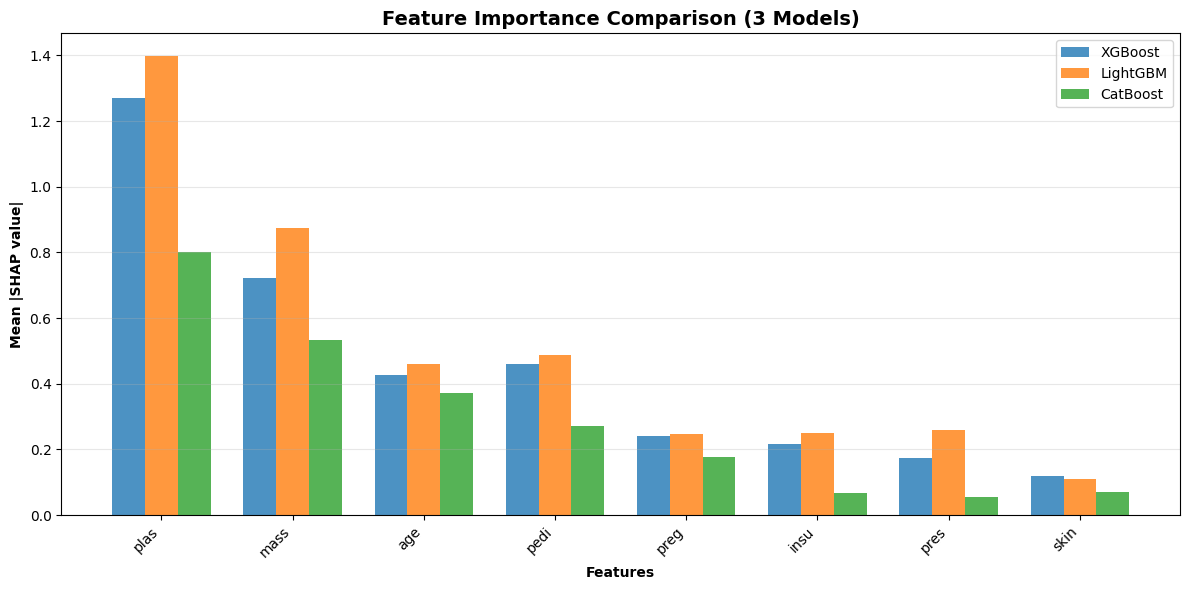

In [39]:
# XGB, LGBM, CAT 각 모델별 특성 중요도 비교하기

# 평균 절대 SHAP 값 계산
importance_xgb = np.abs(shap_values_xgb).mean(axis=0)
importance_lgbm = np.abs(shap_values_lgbm).mean(axis=0)
importance_cat = np.abs(shap_values_cat).mean(axis=0)

# 중요도 DataFrame 생성
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'XGBoost': importance_xgb,
    'LightGBM': importance_lgbm,
    'CatBoost': importance_cat
})

# 평균 중요도로 정렬
importance_df['Mean'] = importance_df[['XGBoost','LightGBM','CatBoost']].mean(axis=1)
importance_df = importance_df.sort_values('Mean', ascending = False)

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(feature_names))
width = 0.25

ax.bar(x - width, importance_df['XGBoost'], width, label='XGBoost', alpha=0.8)
ax.bar(x, importance_df['LightGBM'], width, label='LightGBM', alpha=0.8)
ax.bar(x + width, importance_df['CatBoost'], width, label='CatBoost', alpha=0.8)

ax.set_xlabel('Features', fontweight='bold')
ax.set_ylabel('Mean |SHAP value|', fontweight='bold')
ax.set_title('Feature Importance Comparison (3 Models)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(importance_df['Feature'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Local Interpretation(개별 예측 해석, 당뇨병 양성/음성 예측 샘플 분석)

**지역적 해석**
- 특정 샘플의 예측을 상세히 분석
- Force Plot: 각 특성이 예측에 어떻게 기여했는지 시각화
- Waterfall Plot: 기본 값에서 최종 예측까지의 변화 과정

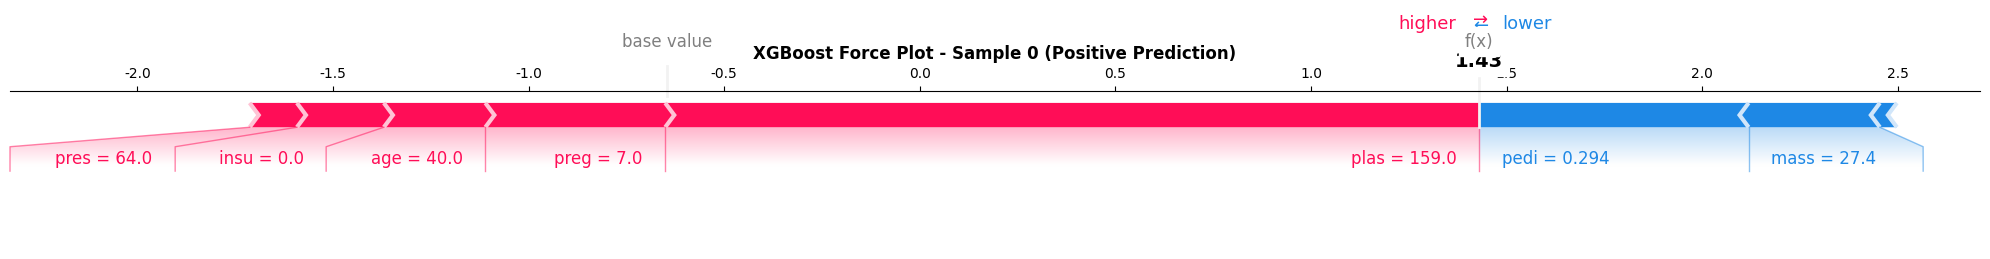

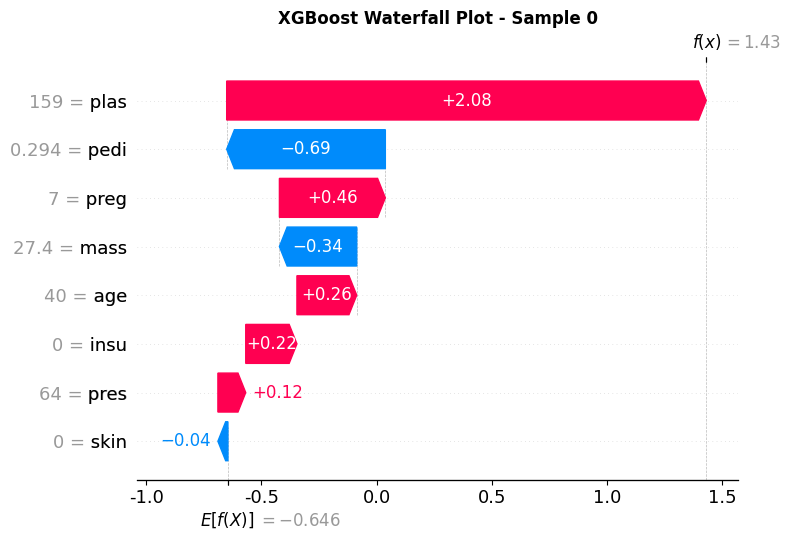

In [40]:
# 당뇨병 양성으로 예측된 샘플 찾기 - 정확도가 가장 높았던 XGBoost를 대표로 분석.
positive_indices = np.where(xgb_pred==1)[0]
if len(positive_indices)>0:
    sample_idx = positive_indices[0]

    # 실제 레이블
    actual = y_test.iloc[sample_idx]
    predicted = xgb_pred[sample_idx]

    # Force Plot(정적 이미지)
    shap.force_plot(
        explainer_xgb.expected_value,
        shap_values_xgb[sample_idx],
        X_test.iloc[sample_idx],
        matplotlib=True,
        show=False
    )
    plt.title(f'XGBoost Force Plot - Sample {sample_idx} (Positive Prediction)',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Waterfall Plot
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_xgb[sample_idx],
            base_values=explainer_xgb.expected_value,
            data=X_test.iloc[sample_idx].values,
            feature_names=feature_names
        ),
        show=False
    )
    plt.title(f'XGBoost Waterfall Plot - Sample {sample_idx}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("양성으로 예측된 샘플이 없습니다.")

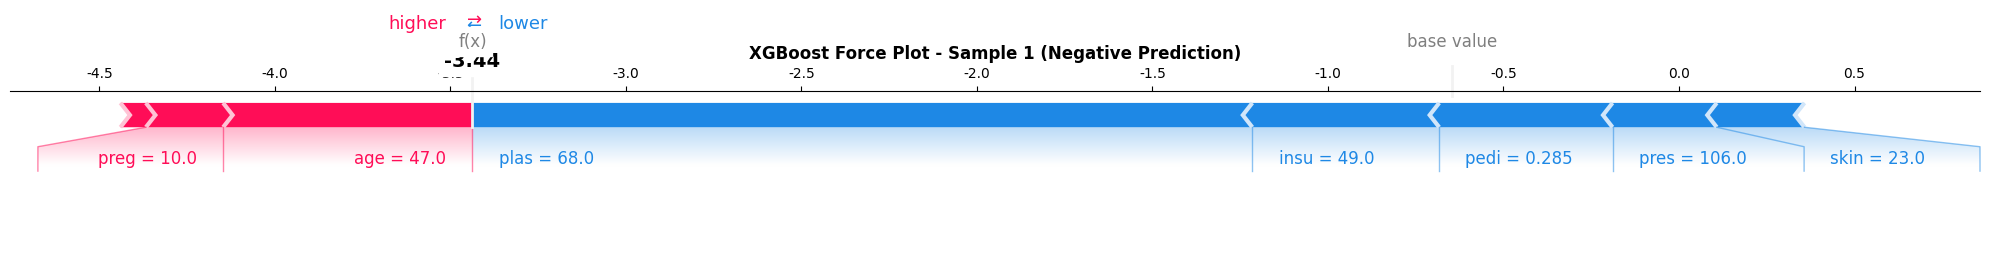

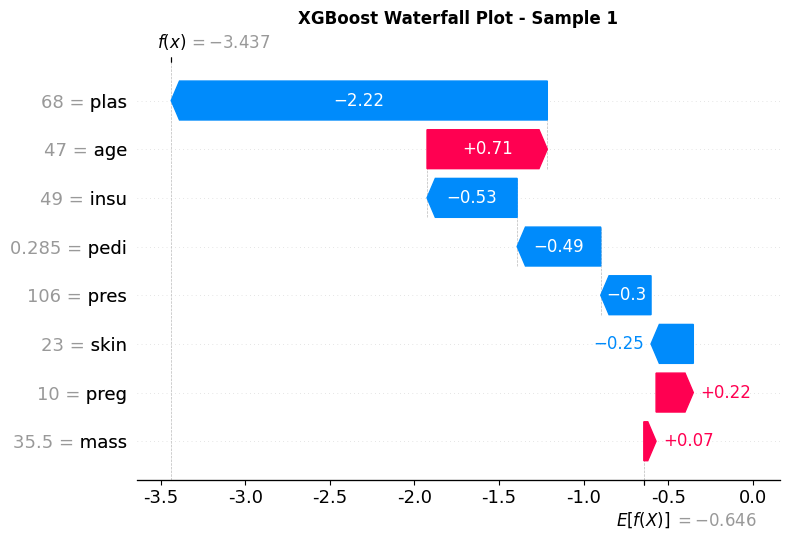

In [41]:
# 당뇨병을 음성으로 예측된 샘플 찾기
negative_indices = np.where(xgb_pred == 0)[0]
if len(negative_indices) > 0:
    sample_idx = negative_indices[0]

    # 실제 레이블
    actual = y_test.iloc[sample_idx]
    predicted = xgb_pred[sample_idx]

    # Force Plot
    shap.force_plot(
        explainer_xgb.expected_value,
        shap_values_xgb[sample_idx],
        X_test.iloc[sample_idx],
        matplotlib=True,
        show=False
    )
    plt.title(f'XGBoost Force Plot - Sample {sample_idx} (Negative Prediction)',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Waterfall Plot
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_xgb[sample_idx],
            base_values=explainer_xgb.expected_value,
            data=X_test.iloc[sample_idx].values,
            feature_names=feature_names
        ),
        show=False
    )
    plt.title(f'XGBoost Waterfall Plot - Sample {sample_idx}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("음성으로 예측된 샘플이 없습니다.")

## 6. Dependence Plot(특성별 의존성 분석)

**Dependence Plot**
- 특정 특성의 값이 변할 때 SHAP 값이 어떻게 변하는지 분석
- 특성 간 상호작용 파악

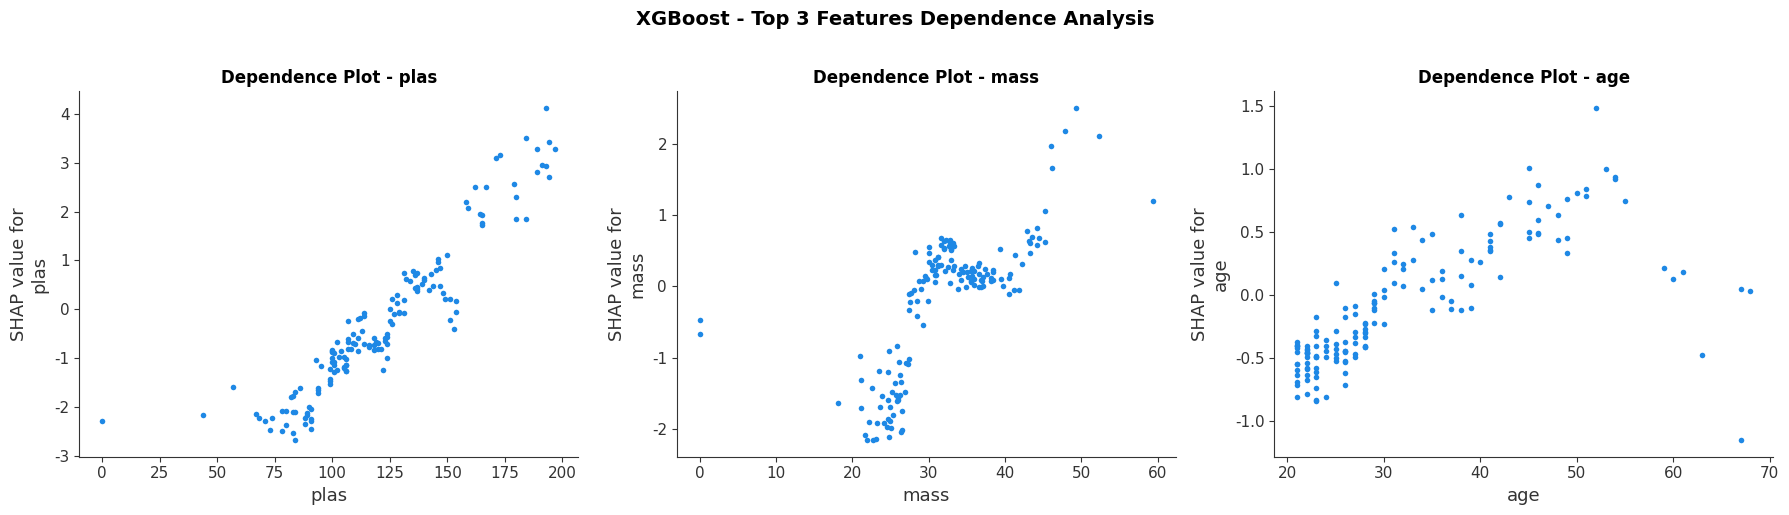

In [44]:
# 상위 3개 중요 특성
top_3_features = importance_df.head(3)['Feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(top_3_features):
    feature_idx = feature_names.index(feature)
    shap.dependence_plot(
        feature_idx,
        shap_values_xgb,
        X_test,
        interaction_index=None,
        feature_names=feature_names,
        ax=axes[idx],
        show=False
    )
    axes[idx].set_title(f'Dependence Plot - {feature}', fontweight='bold')

plt.suptitle('XGBoost - Top 3 Features Dependence Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. 특성 간 상호작용 분석

**상호작용 효과**
- 두 특성이 함께 예측에 미치는 영향
- 상호작용 강도 계산


분석 대상: plas vs mass


<Figure size 1000x600 with 0 Axes>

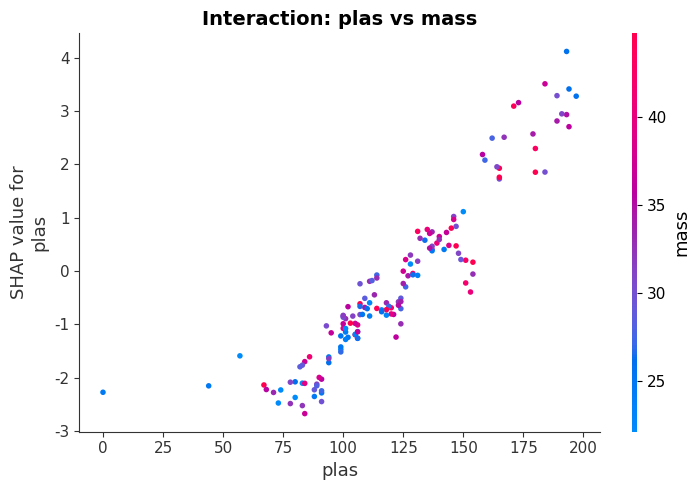

In [45]:
# 상위 2개 특성 간 상호작용
if len(top_3_features) >= 2:
    feature1 = top_3_features[0]
    feature2 = top_3_features[1]

    feature1_idx = feature_names.index(feature1)
    feature2_idx = feature_names.index(feature2)

    print(f"\n분석 대상: {feature1} vs {feature2}")

    # Dependence Plot with interaction
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        feature1_idx,
        shap_values_xgb,
        X_test,
        feature_names=feature_names,
        interaction_index=feature2_idx,
        show=False
    )
    plt.title(f'Interaction: {feature1} vs {feature2}',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. Decision Plot(의사결정 과정 시각화)

**Decision Plot**
- 여러 샘플의 의사결정 과정을 동시에 비교
- 각 특성이 순차적으로 예측에 기여하는 과정 추적

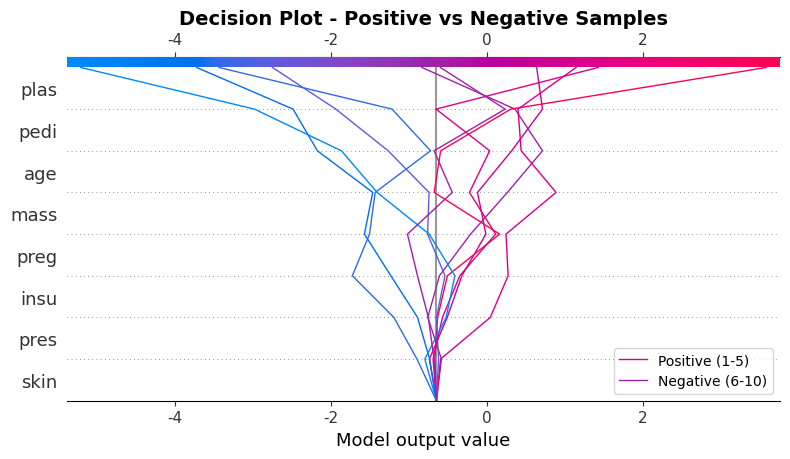

In [48]:
# 양성/음성 각 5개 샘플 선택
positive_samples = np.where(y_test == 1)[0][:5]
negative_samples = np.where(y_test == 0)[0][:5]
selected_samples = np.concatenate([positive_samples, negative_samples])

# Decision Plot
plt.figure(figsize=(12, 8))
shap.decision_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[selected_samples],
    X_test.iloc[selected_samples],
    feature_names=feature_names,
    show=False,
    legend_labels=['Positive (1-5)', 'Negative (6-10)'],
    legend_location='lower right'
)
plt.title('Decision Plot - Positive vs Negative Samples',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. 종합 분석 및 인사이트

In [51]:
print("\n📊 주요 발견사항:")
print("-" * 80)

# 1. 가장 중요한 특성 Top 3
print("\n1️⃣ 가장 중요한 특성 (3가지 모델 평균):")
for i, row in importance_df.head(3).iterrows():
    print(f"   {row['Feature']}: {row['Mean']:.4f}")

# 2. 모델 간 일치도
print("\n2️⃣ 모델 성능 비교:")
print(f"   XGBoost:  {xgb_acc:.4f}")
print(f"   LightGBM: {lgbm_acc:.4f}")
print(f"   CatBoost: {cat_acc:.4f}")

# 3. 특성별 영향 방향
print("\n3️⃣ 주요 특성의 영향:")
for feature in top_3_features[:3]:
    feature_idx = feature_names.index(feature)
    mean_shap = shap_values_xgb[:, feature_idx].mean()
    direction = "양성 예측" if mean_shap > 0 else "음성 예측"
    print(f"   {feature}: 평균적으로 {direction}에 기여 (mean SHAP: {mean_shap:.4f})")

print("\n\n💡 실무 활용 방안:")
print("-" * 80)
print("\n1️⃣ 의료 진단 보조:")
print("   • 의사가 AI 예측을 신뢰할 수 있도록 근거 제시")
print("   • 환자에게 당뇨병 위험 요인 설명")
print("   • 잘못된 예측의 원인 분석")

print("\n2️⃣ 모델 개선:")
print("   • 중요하지 않은 특성 제거 (모델 단순화)")
print("   • 중요한 특성의 데이터 품질 개선")
print("   • 특성 간 상호작용을 활용한 파생 변수 생성")

print("\n3️⃣ 공정성 검증:")
print("   • 나이, 성별 등 민감 속성의 과도한 영향 확인")
print("   • 편향된 예측 패턴 탐지")
print("   • 규제 준수 (설명 가능한 AI)")

print("\n4️⃣ 비즈니스 인사이트:")
print("   • 당뇨병 고위험군 특성 파악")
print("   • 예방 프로그램 타겟팅")
print("   • 건강 관리 서비스 개선")



📊 주요 발견사항:
--------------------------------------------------------------------------------

1️⃣ 가장 중요한 특성 (3가지 모델 평균):
   plas: 1.1562
   mass: 0.7103
   age: 0.4193

2️⃣ 모델 성능 비교:
   XGBoost:  0.7792
   LightGBM: 0.7727
   CatBoost: 0.7403

3️⃣ 주요 특성의 영향:
   plas: 평균적으로 음성 예측에 기여 (mean SHAP: -0.2726)
   mass: 평균적으로 음성 예측에 기여 (mean SHAP: -0.2083)
   age: 평균적으로 음성 예측에 기여 (mean SHAP: -0.0784)


💡 실무 활용 방안:
--------------------------------------------------------------------------------

1️⃣ 의료 진단 보조:
   • 의사가 AI 예측을 신뢰할 수 있도록 근거 제시
   • 환자에게 당뇨병 위험 요인 설명
   • 잘못된 예측의 원인 분석

2️⃣ 모델 개선:
   • 중요하지 않은 특성 제거 (모델 단순화)
   • 중요한 특성의 데이터 품질 개선
   • 특성 간 상호작용을 활용한 파생 변수 생성

3️⃣ 공정성 검증:
   • 나이, 성별 등 민감 속성의 과도한 영향 확인
   • 편향된 예측 패턴 탐지
   • 규제 준수 (설명 가능한 AI)

4️⃣ 비즈니스 인사이트:
   • 당뇨병 고위험군 특성 파악
   • 예방 프로그램 타겟팅
   • 건강 관리 서비스 개선


## 10. 추가 분석 - Confusion Matrix & SHAP


예측 성능 분석


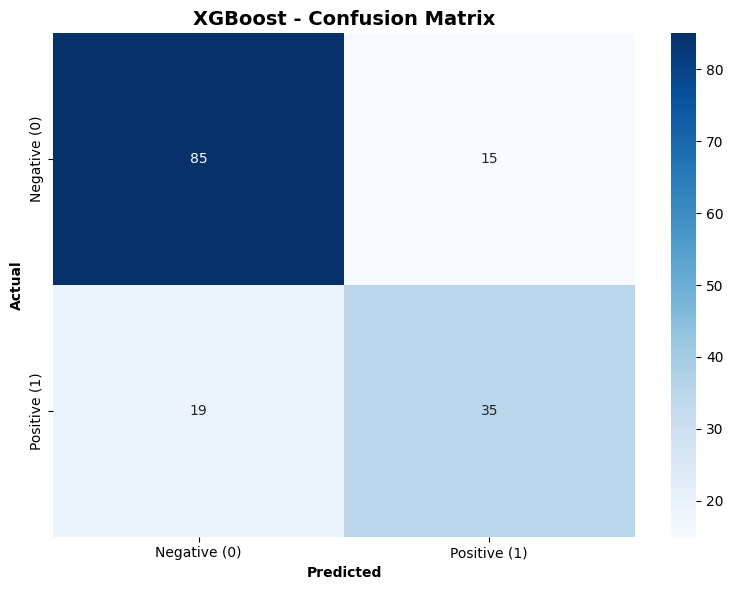


Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.82      0.85      0.83       100
Positive (1)       0.70      0.65      0.67        54

    accuracy                           0.78       154
   macro avg       0.76      0.75      0.75       154
weighted avg       0.78      0.78      0.78       154


잘못 예측된 샘플 수: 34개 (22.1%)

잘못 예측된 샘플의 SHAP 값 분석:

잘못된 예측에 가장 영향을 준 특성:
   plas: 1.1586
   mass: 0.5935
   pedi: 0.4710
   age: 0.4034
   preg: 0.2670


In [52]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("\n" + "="*60)
print("예측 성능 분석")
print("="*60)

# XGBoost Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.xlabel('Predicted', fontweight='bold')
plt.tight_layout()
plt.show()

# 분류 리포트
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred,
                          target_names=['Negative (0)', 'Positive (1)']))

# 잘못 예측된 샘플 분석
misclassified = np.where(y_test.values != xgb_pred)[0]
print(f"\n잘못 예측된 샘플 수: {len(misclassified)}개 ({len(misclassified)/len(y_test)*100:.1f}%)")

if len(misclassified) > 0:
    print("\n잘못 예측된 샘플의 SHAP 값 분석:")
    misclassified_shap = np.abs(shap_values_xgb[misclassified]).mean(axis=0)

    # 정렬
    sorted_indices = np.argsort(misclassified_shap)[::-1]
    print("\n잘못된 예측에 가장 영향을 준 특성:")
    for i in range(min(5, len(sorted_indices))):
        idx = sorted_indices[i]
        print(f"   {feature_names[idx]}: {misclassified_shap[idx]:.4f}")